# *Aufgabe: Baummethoden*

0. Imports

In [34]:
# Importiere alle Bibliotheken/ Funktionen, die später benötigt werden
# Zum Beispiel für das Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  # zur Darstellung
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier  # Die Modelle
from sklearn.datasets import load_diabetes  # Den Datensatz aus der Aufgabe
from tqdm import trange # zur Darstellung des prozentualen Fortschritts in for-Loop

import pandas as pd
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
import os

from sklearn.metrics import accuracy_score
import sklearn


### Aufgabe 1. Baummethoden

Implementieren Sie ein Decision Tree Modell für Klassifikationsaufgaben aus [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) und sagen Sie damit den Gehalt von Menschen auf Grundlage ihrer sozioökonomischen Attribute vorher. Nutzen Sie dafür den bereitgestellten Census Datensatz. Achten Sie darauf, dass der Datensatz vorverarbeitet werden muss, da es zahlreiche kategorische Features und fehlende Werte gibt. 

Messen Sie die Leistungsfähigkeit Ihres Modells in Abhängigkeit von der maximalen Tiefe mit einer passenden Metrik.


#### Data Preprocessing

            age  sex  hours-per-week  Local-gov  Never-worked  Private  \
16664 -0.849088    1       -0.034763       True         False    False   
10421 -0.042104    1       -0.034763      False         False     True   
20829  1.938675    0        1.258834      False         False     True   
16004  1.865313    1       -0.034763      False         False     True   
13063 -1.362623    1       -0.034763      False         False    False   

       Self-emp-inc  Self-emp-not-inc  State-gov  Without-pay  ...  \
16664         False             False      False        False  ...   
10421         False             False      False        False  ...   
20829         False             False      False        False  ...   
16004         False             False      False        False  ...   
13063         False             False       True        False  ...   

       Married-AF-spouse  Married-civ-spouse  Married-spouse-absent  \
16664              False               False                  F

C:\Users\fried\AppData\Local\Temp\ipykernel_91280\1035777923.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})
C:\Users\fried\AppData\Local\Temp\ipykernel_91280\1035777923.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census["sex"] = census["sex"].replace({" Male": 1, " Female": 0})


TypeError: 'str' object is not callable

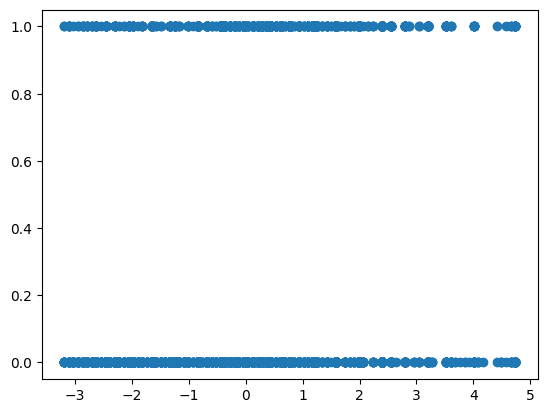

In [ ]:
# Vorbereitung wie aus dem letzten Notebook DS01_Lösung_kNN_und_Data_Preprocessing
# Einlesen des Datensatzes
from sklearn.discriminant_analysis import StandardScaler


census = pd.read_csv(os.path.join("..", "..", "..", "data", "census.csv"))
census = census.drop(
    ["occupation", "relationship", "capital-gain", "capital-loss", "native-country"],
    axis=1,
)
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})
census["sex"] = census["sex"].replace({" Male": 1, " Female": 0})
# Imputen
for col in census.select_dtypes(include="object"):
    census[col] = census[col].str.strip()

col_missing = [col for col in census.columns if "?" in census[col].values]
imp_most_frequent = SimpleImputer(missing_values="?", strategy="most_frequent")
census[col_missing[0]] = imp_most_frequent.fit_transform(
    census[col_missing[0]].to_numpy().reshape(-1, 1)
).reshape(census.shape[0])

#for col in col_missing:
#    print(f"\n=== {col} ===")
#    print(census[col].value_counts())


# Encoden (OneHotEncoding notwendig für DecisionTree, da diese nur mit numerischen Daten umgehen können)

# Alle kategorischen Variablen sollten in diesem Fall encoded werden

to_encode = ["workclass", "education", "marital-status", "race"]
for feature in to_encode:
    # Benutze dummy codierung von pandas
    one_hot = pd.get_dummies(census[feature], drop_first=True)
    census = census.join(one_hot)
    census.pop(feature)

# Nachsehen wie viele Feature die Dummykodierung ergibt
#census.shape

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(
    census.drop(["target"], axis=1), census["target"]
)

# Standardisieren
# Age und hours-per-week sollten normalisiert werden
scaled_columns = ["age", "hours-per-week"]

# Initalisieren des Scalers
scaler = StandardScaler() # nicht notwendig!

# Fitte den Scaler auf die Trainingsdaten und wende ihn an
x_train[scaled_columns] = scaler.fit_transform(x_train[scaled_columns])
print(x_train.head())

# Wende denselben gefitetten Scaler auf die Testdaten an
x_test[scaled_columns] = scaler.transform(x_test[scaled_columns])
x_test.head()

plt.scatter(x_train["hours-per-week"], y_train)
plt.xlabel("hours-per-week")
plt.ylabel("target")
plt.show()

#census.head()


#### Trainieren der Bäume für verschiedene Tiefen

100%|██████████| 29/29 [00:02<00:00, 11.08it/s]


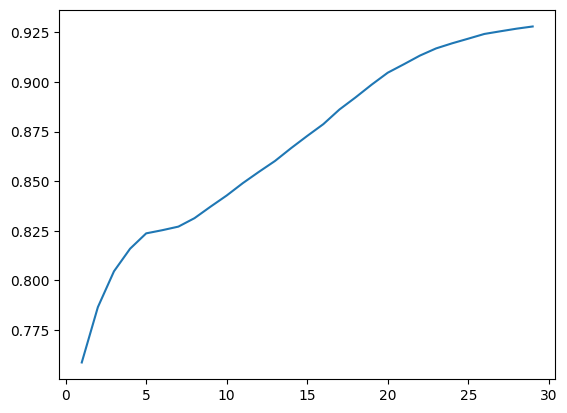

In [ ]:
# Gehe durch die möglichen Tiefen von 1 bis 20 (zum Beispiel)
score = []
for depth in trange(1, 30):  # trange zeigt den prozentualen Fortschritt an
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)
    score.append(model.score(x_train, y_train))

# Darstellung der Accuracy über den verschiedenen Tiefen der Bäume
plt.plot(range(1, 30), score)
plt.xlabel = "max_depth"
plt.ylabel = "accuracy"
plt.show()


100%|██████████| 29/29 [00:02<00:00, 12.95it/s]


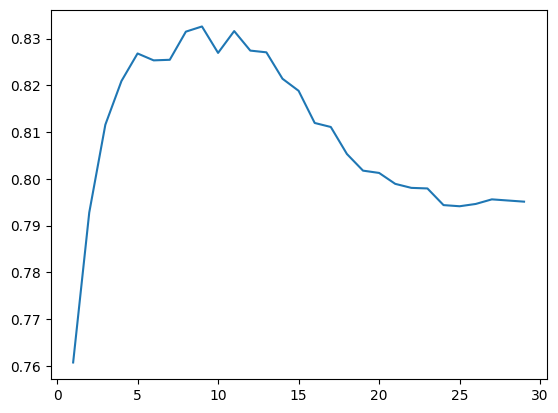

In [91]:
score = []
for depth in trange(1, 30):  # trange zeigt den prozentualen Fortschritt an
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score.append(accuracy_score(y_pred, y_test))

# Darstellung der Accuracy über den verschiedenen Tiefen der Bäume
plt.plot(range(1, 30), score)
plt.xlabel = "max_depth"
plt.ylabel = "accuracy"
plt.show()


### Aufgabe 2. Visualisierung von Baummethoden Regressor

Trainieren Sie einen Decision Tree Regressor (DTR) auf den [Diabetes Datensatz](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes) aus sklearn. Dieser Datensatz gibt Risikofaktoren für Diabetes (Alter, BMI, ..) und einen Risikoscore für Diabetes. Regressieren Sie mittels eines DTR den Risikoscore. Zeigen Sie dann für das Attribut BMI auf, wie ein DTR diesen Wert nutzt, um auf den Risikoscore zu regressieren. Trainieren Sie dabei DTRs mit verschiedener Tiefe (max_depth=). Bauen Sie grafisch die folgende Darstellung nach:

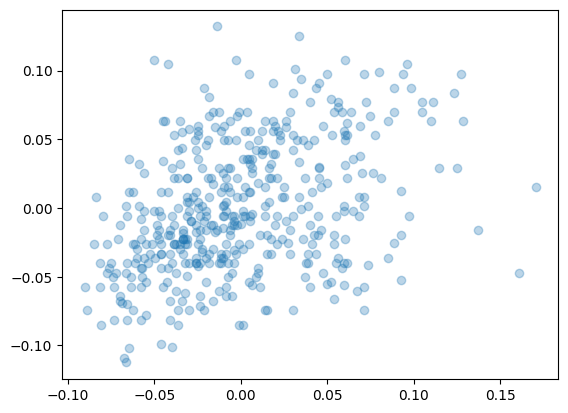

In [95]:
# Einlesen der Daten load_diabetes()
from scipy import stats
import math
import numpy as np
import pandas as pd

diabetes = sklearn.datasets.load_diabetes()
diabetes.keys()
#print(diabetes["feature_names"])
dataset = diabetes["data"]
feature_names = diabetes["feature_names"]

# Lesen sie in der Dokumentation nach wie das Format des Diabetes Datensatz aufgebaut ist

# Das relevante Feature und die Zielvariable
bmi = dataset[:, 2]  # BMI ist das dritte Feature
risk = dataset[:, 3]  # Risk ist das vierte Feature
plt.scatter(bmi, risk, alpha=0.3)
plt.show()


TypeError: 'str' object is not callable

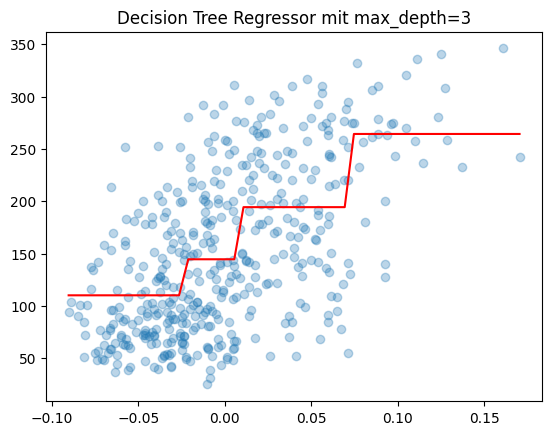

In [104]:
from scipy import stats
import math
import numpy as np
import pandas as pd
from sklearn import tree


#Datern laden und zusammenführen
diabetes = sklearn.datasets.load_diabetes()
#diabetes.keys()
x = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y= diabetes.target
full = x.copy()
full["target"] = y
x_train, x_test, y_train, y_test = train_test_split(x, y)

minimum, maximum = full["bmi"].min(), full["bmi"].max()
x_range = np.linspace(minimum, maximum)
tree_bmi = DecisionTreeRegressor(max_depth=2)
tree_bmi.fit(x_train["bmi"].to_numpy().reshape(-1, 1), y_train)
tree_bmi.predict(x_range.reshape(-1, 1))
plt.scatter(full["bmi"], full["target"], alpha=0.3)
plt.plot(x_range, tree_bmi.predict(x_range.reshape(-1, 1)), color="red")
plt.title("Decision Tree Regressor mit max_depth=3")
plt.xlabel("BMI")
plt.ylabel("Diabetes Score")

plt.figure(figsize=(20, 10))
tree.plot_tree(
    tree_bmi, proportion=True, feature_names=["bmi"], filled=True,fontsize=10
)
plt.show()

#### Datensatzbeschreibung

C:\Users\fried\AppData\Local\Temp\ipykernel_91280\1449311712.py:10: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  density = stats.kde.gaussian_kde(col_data)


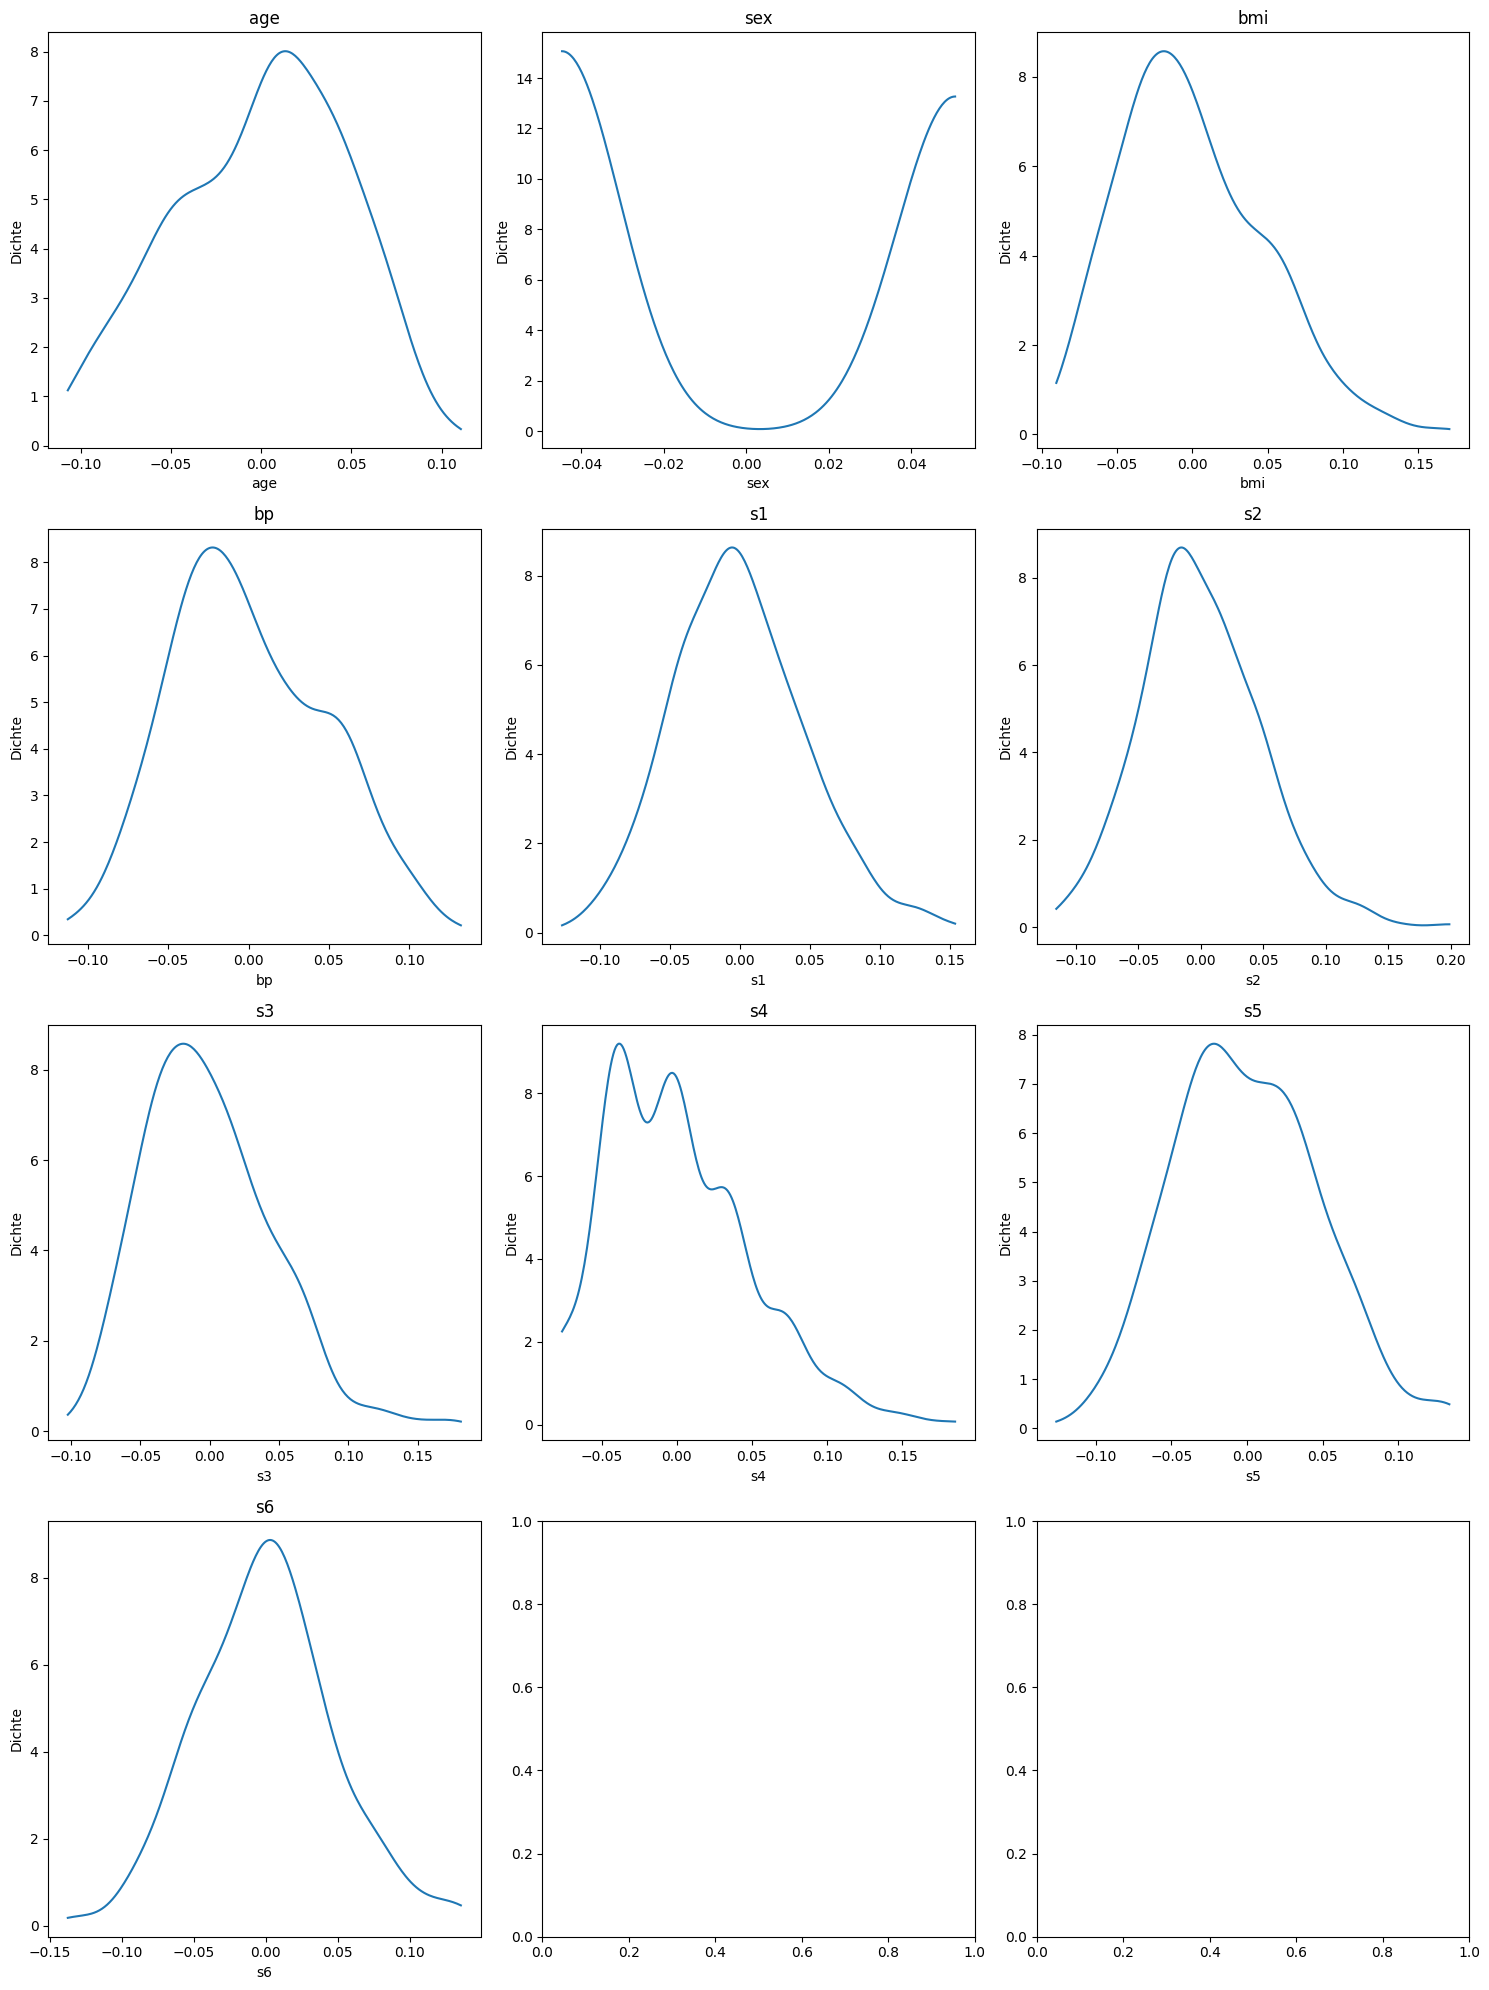

In [ ]:
n_features = dataset.shape[1]
n_cols_subplot = 3
n_rows = math.ceil(n_features / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i in range(n_features):
    col_data = dataset[:, i]
    density = stats.kde.gaussian_kde(col_data)
    x = np.linspace(col_data.min(), col_data.max(), 300)
    axes[i].plot(x, density(x))
    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel("Dichte")

# Verstecke leere Subplots, falls weniger Spalten als Plätze
for j in range(len(dataset), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Trainieren der Modelle und Visualisierung:

In [ ]:
# X-Achsen Definition zur späteren Darstellung
# x_axis = np.linspace(-0.1, 0.2, 1500).reshape(-1,1)

# for i in range(1, 10):

    # Darstellung von BMI und Risiko

    # Trainieren des Regressors für verschiedene Tiefen

    # Vorhersagen des Risikos

    # Visualisiere das Modell für BMI und Risiko


'max_depth'

### Mehrere features trainiern

100%|██████████| 9/9 [00:00<00:00, 162.95it/s]


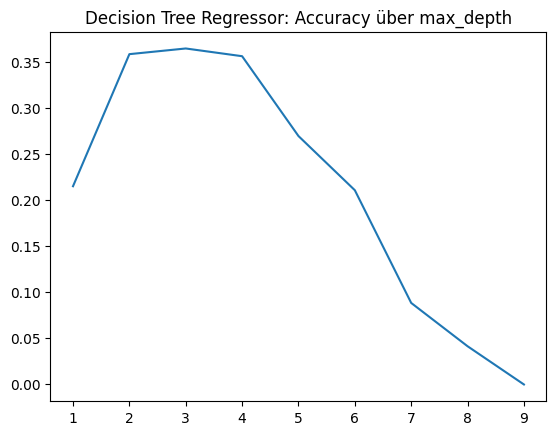

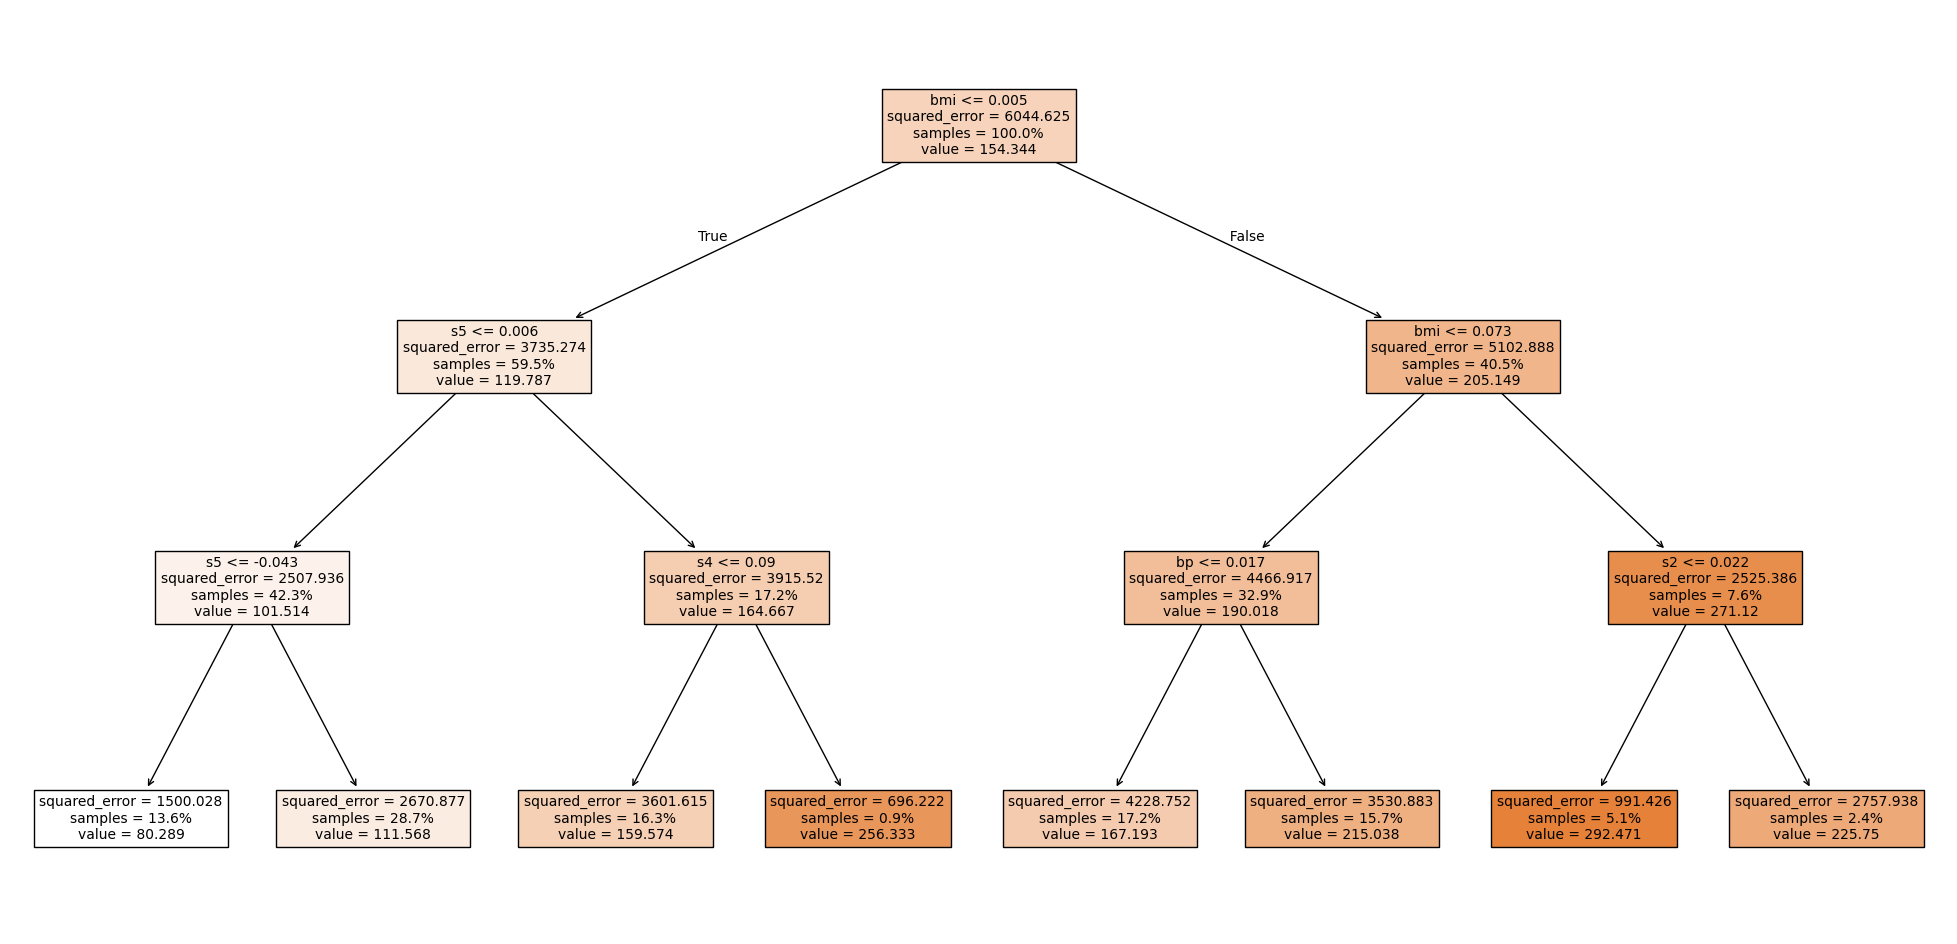

In [110]:
# Daten laden
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Decision Tree auf alle Features trainieren
error=[]
for depth in trange(1, 10):  # trange zeigt den prozentualen Fortschritt an
    tree_all = DecisionTreeRegressor(max_depth=depth)
    tree_all.fit(x_train, y_train)
    error.append(tree_all.score(x_test, y_test))

plt.plot(range(1, 10), error)
plt.title("Decision Tree Regressor: Accuracy über max_depth")
plt.xlabel = "max_depth"
plt.ylabel = "accuracy"
plt.show()

# Baum plotten
plt.figure(figsize=(25, 12))
tree_plot = DecisionTreeRegressor(max_depth=3)
tree_plot.fit(x_train, y_train)
tree.plot_tree(
    tree_plot,
    feature_names=diabetes.feature_names,
    filled=True,
    proportion=True,
    fontsize=10,
)
plt.show()
